# Model Selection: CPU vs OpenACC (GPU) Comparison

Comparing IQ-TREE ModelFinder results across 4 workflows:
- **VANILA** (1 CPU thread)
- **OMP_10** (10 CPU threads)
- **OMP_48** (48 CPU threads)
- **OPENACC** (GPU via OpenACC on V100)

Dataset: 100 taxa, GTR+I+G4 simulated DNA, alignment lengths: 100, 1K, 10K, 100K, 1M sites

In [1]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_DIR = '/Users/u7826985/Projects/Nvidia/results/2026_03_23_model_selection/DNA/GTR+I+G4/taxa_100'
SAVE_DIR = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_23_model_selection'

## 1. Parse Results

In [2]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for key metrics."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Best-fit model
    m = re.search(r'Best-fit model according to BIC:\s+(\S+)', content)
    if m: data['best_model'] = m.group(1)
    
    # Log-likelihood
    m = re.search(r'Log-likelihood of the tree:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))
    
    # BIC score
    m = re.search(r'Bayesian information criterion \(BIC\) score:\s+([\d.]+)', content)
    if m: data['bic'] = float(m.group(1))
    
    # AIC score
    m = re.search(r'Akaike information criterion \(AIC\) score:\s+([\d.]+)', content)
    if m: data['aic'] = float(m.group(1))
    
    # Free parameters
    m = re.search(r'Number of free parameters.*?:\s+(\d+)', content)
    if m: data['free_params'] = int(m.group(1))
    
    # Gamma shape
    m = re.search(r'Gamma shape alpha:\s+([\d.]+)', content)
    if m: data['gamma_alpha'] = float(m.group(1))
    
    # Wall-clock time
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))
    
    # CPU time
    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))
    
    return data

def parse_log_file(filepath):
    """Parse .log file as fallback."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()
    
    m = re.search(r'Best-fit model:\s+(\S+)\s+chosen', content)
    if m: data['best_model'] = m.group(1)
    
    m = re.search(r'Optimal log-likelihood:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))
    
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))
    
    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))
    
    return data

# Collect all results
records = []
lengths = [100, 1000, 10000, 100000, 1000000]
workflows = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']

for length in lengths:
    tree_dir = os.path.join(RESULTS_DIR, f'len_{length}', 'tree_1')
    if not os.path.isdir(tree_dir):
        continue
    for wf in workflows:
        # Try .iqtree first
        iqtree_files = glob.glob(os.path.join(tree_dir, f'*_{wf}_*.iqtree'))
        if iqtree_files:
            data = parse_iqtree_file(iqtree_files[0])
        else:
            # Fallback to .log
            log_files = glob.glob(os.path.join(tree_dir, f'*_{wf}_*.log'))
            if log_files:
                data = parse_log_file(log_files[0])
            else:
                continue
        
        if not data or 'wall_time_sec' not in data:
            continue  # Skip incomplete runs
        
        data['length'] = length
        data['workflow'] = wf
        records.append(data)

df = pd.DataFrame(records)
# Rename workflows for display
wf_labels = {'VANILA': '1 CPU', 'OMP_10': '10 CPUs', 'OMP_48': '48 CPUs', 'OPENACC': 'GPU (V100)'}
df['workflow_label'] = df['workflow'].map(wf_labels)
df = df.sort_values(['length', 'workflow'])
print(f"Parsed {len(df)} result entries")
df[['length', 'workflow_label', 'best_model', 'log_likelihood', 'wall_time_sec', 'cpu_time_sec']].to_string(index=False)

Parsed 17 result entries


' length workflow_label   best_model  log_likelihood  wall_time_sec  cpu_time_sec\n    100     GPU (V100) F81+F+ASC+G4   -4.907728e+03       73.22810       71.9455\n   1000        10 CPUs     F81+F+G4   -5.618215e+04        8.22419       81.6723\n   1000        48 CPUs     F81+F+G4   -5.618215e+04       19.84740      937.3680\n   1000     GPU (V100)     F81+F+G4   -5.618215e+04       41.62070       41.5920\n   1000          1 CPU     F81+F+G4   -5.618215e+04       27.58650       27.4070\n  10000        10 CPUs     F81+F+G4   -5.642088e+05      127.60000     1173.6000\n  10000        48 CPUs     F81+F+G4   -5.642088e+05       64.76490     2946.4300\n  10000     GPU (V100)     F81+F+G4   -5.642088e+05       78.57070       78.4466\n  10000          1 CPU     F81+F+G4   -5.642088e+05      431.46600      426.5890\n 100000        10 CPUs     F81+F+G4   -5.692985e+06      637.98820     5875.4280\n 100000        48 CPUs     F81+F+G4   -5.692985e+06      205.77710     9193.5630\n 100000     GPU

In [3]:
# Display full summary table
display_cols = ['length', 'workflow_label', 'best_model', 'log_likelihood', 'wall_time_sec', 'cpu_time_sec']
extra_cols = [c for c in ['bic', 'aic', 'gamma_alpha', 'free_params'] if c in df.columns]
display_df = df[display_cols + extra_cols].copy()
display_df.columns = ['Sites', 'Workflow', 'Best Model', 'Log-Likelihood', 'Wall Time (s)', 'CPU Time (s)'] + \
    [{'bic': 'BIC', 'aic': 'AIC', 'gamma_alpha': 'Gamma α', 'free_params': '# Params'}[c] for c in extra_cols]
display_df

,Sites,Workflow,Best Model,Log-Likelihood,Wall Time (s),CPU Time (s),BIC,AIC,Gamma α,# Params
0,100,GPU (V100),F81+F+ASC+G4,-4.907728e+03,73.22810,71.9455,1.074109e+04,1.021746e+04,0.8172,201
2,1000,10 CPUs,F81+F+G4,-5.618215e+04,8.22419,81.6723,1.137528e+05,1.127663e+05,1.0080,201
3,1000,48 CPUs,F81+F+G4,-5.618215e+04,19.84740,937.3680,1.137528e+05,1.127663e+05,1.0080,201
4,1000,GPU (V100),F81+F+G4,-5.618215e+04,41.62070,41.5920,1.137528e+05,1.127663e+05,1.0080,201
1,1000,1 CPU,F81+F+G4,-5.618215e+04,27.58650,27.4070,1.137528e+05,1.127663e+05,1.0080,201
6,10000,10 CPUs,F81+F+G4,-5.642088e+05,127.60000,1173.6000,1.130269e+06,1.128820e+06,0.9844,201
7,10000,48 CPUs,F81+F+G4,-5.642088e+05,64.76490,2946.4300,1.130269e+06,1.128820e+06,0.9843,201
8,10000,GPU (V100),F81+F+G4,-5.642088e+05,78.57070,78.4466,1.130269e+06,1.128820e+06,0.9844,201
5,10000,1 CPU,F81+F+G4,-5.642088e+05,431.46600,426.5890,1.130269e+06,1.128820e+06,0.9843,201
10,100000,10 CPUs,F81+F+G4,-5.692985e+06,637.98820,5875.4280,1.138828e+07,1.138637e+07,1.0090,201


## 2. Model Selection Agreement

In [4]:
# Check if all workflows select the same model for each alignment length
model_pivot = df.pivot_table(index='length', columns='workflow_label', values='best_model', aggfunc='first')
model_pivot = model_pivot[['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)']]
print("Best-fit model selected by each workflow:")
print(model_pivot.to_string())
print()

# Check agreement
for length in model_pivot.index:
    models = model_pivot.loc[length].dropna().unique()
    status = '✓ AGREE' if len(models) == 1 else f'✗ DISAGREE: {models}'
    print(f"  len={length:>8d}: {status} → {models[0]}")

Best-fit model selected by each workflow:
workflow_label     1 CPU   10 CPUs   48 CPUs    GPU (V100)
length                                                    
100                  NaN       NaN       NaN  F81+F+ASC+G4
1000            F81+F+G4  F81+F+G4  F81+F+G4      F81+F+G4
10000           F81+F+G4  F81+F+G4  F81+F+G4      F81+F+G4
100000          F81+F+G4  F81+F+G4  F81+F+G4      F81+F+G4
1000000         F81+F+G4  F81+F+G4  F81+F+G4      F81+F+G4

  len=     100: ✓ AGREE → F81+F+ASC+G4
  len=    1000: ✓ AGREE → F81+F+G4
  len=   10000: ✓ AGREE → F81+F+G4
  len=  100000: ✓ AGREE → F81+F+G4
  len= 1000000: ✓ AGREE → F81+F+G4


## 3. Log-Likelihood Comparison

In [5]:
# Compare log-likelihoods across workflows
lnl_pivot = df.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
cols_order = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in lnl_pivot.columns]
lnl_pivot = lnl_pivot[cols_order]

print("Log-Likelihood values:")
print(lnl_pivot.to_string())
print()

# Calculate differences vs 1 CPU baseline
if '1 CPU' in lnl_pivot.columns:
    print("Absolute difference from 1 CPU baseline:")
    for col in cols_order:
        if col != '1 CPU':
            diff = (lnl_pivot[col] - lnl_pivot['1 CPU']).dropna()
            for idx in diff.index:
                print(f"  len={idx:>8d}, {col:>12s} vs 1 CPU: Δ = {diff[idx]:.6f}")

Log-Likelihood values:
workflow_label         1 CPU       10 CPUs       48 CPUs    GPU (V100)
length                                                                
100                      NaN           NaN           NaN -4.907728e+03
1000           -5.618215e+04 -5.618215e+04 -5.618215e+04 -5.618215e+04
10000          -5.642088e+05 -5.642088e+05 -5.642088e+05 -5.642088e+05
100000         -5.692985e+06 -5.692985e+06 -5.692985e+06 -5.692985e+06
1000000        -5.920802e+07 -5.920802e+07 -5.920802e+07 -5.920802e+07

Absolute difference from 1 CPU baseline:
  len=    1000,      10 CPUs vs 1 CPU: Δ = 0.000000
  len=   10000,      10 CPUs vs 1 CPU: Δ = -0.000500
  len=  100000,      10 CPUs vs 1 CPU: Δ = 0.000000
  len= 1000000,      10 CPUs vs 1 CPU: Δ = 0.000000
  len=    1000,      48 CPUs vs 1 CPU: Δ = 0.000000
  len=   10000,      48 CPUs vs 1 CPU: Δ = 0.000000
  len=  100000,      48 CPUs vs 1 CPU: Δ = 0.000000
  len= 1000000,      48 CPUs vs 1 CPU: Δ = 0.000000
  len=    1000,   GPU

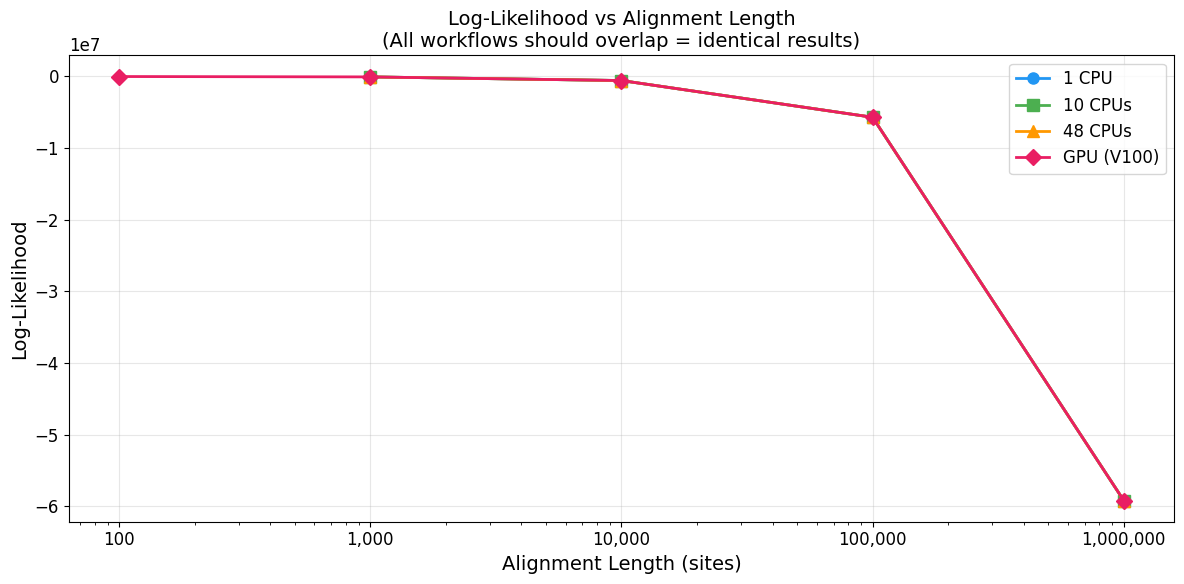

In [6]:
# Plot log-likelihood comparison
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'1 CPU': '#2196F3', '10 CPUs': '#4CAF50', '48 CPUs': '#FF9800', 'GPU (V100)': '#E91E63'}
markers = {'1 CPU': 'o', '10 CPUs': 's', '48 CPUs': '^', 'GPU (V100)': 'D'}

for wf in cols_order:
    data = lnl_pivot[wf].dropna()
    ax.plot(data.index, data.values, marker=markers[wf], label=wf, 
            color=colors[wf], linewidth=2, markersize=8)

ax.set_xscale('log')
ax.set_xlabel('Alignment Length (sites)', fontsize=14)
ax.set_ylabel('Log-Likelihood', fontsize=14)
ax.set_title('Log-Likelihood vs Alignment Length\n(All workflows should overlap = identical results)', fontsize=14)
ax.legend(fontsize=12)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'log_likelihood_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Wall-Clock Runtime Comparison

In [7]:
time_pivot = df.pivot_table(index='length', columns='workflow_label', values='wall_time_sec', aggfunc='first')
time_pivot = time_pivot[[c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in time_pivot.columns]]

print("Wall-clock time (seconds):")
print(time_pivot.to_string(float_format='%.1f'))
print()

# Convert to human-readable
def fmt_time(sec):
    if pd.isna(sec): return 'N/A'
    if sec < 60: return f'{sec:.1f}s'
    if sec < 3600: return f'{sec/60:.1f}m'
    return f'{sec/3600:.1f}h'

print("\nWall-clock time (human-readable):")
print(time_pivot.map(fmt_time).to_string())

Wall-clock time (seconds):
workflow_label   1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                              
100                NaN      NaN      NaN        73.2
1000              27.6      8.2     19.8        41.6
10000            431.5    127.6     64.8        78.6
100000          3682.0    638.0    205.8       127.0
1000000        95785.9  15910.6   8121.2      2333.0


Wall-clock time (human-readable):
workflow_label  1 CPU 10 CPUs 48 CPUs GPU (V100)
length                                          
100               N/A     N/A     N/A       1.2m
1000            27.6s    8.2s   19.8s      41.6s
10000            7.2m    2.1m    1.1m       1.3m
100000           1.0h   10.6m    3.4m       2.1m
1000000         26.6h    4.4h    2.3h      38.9m


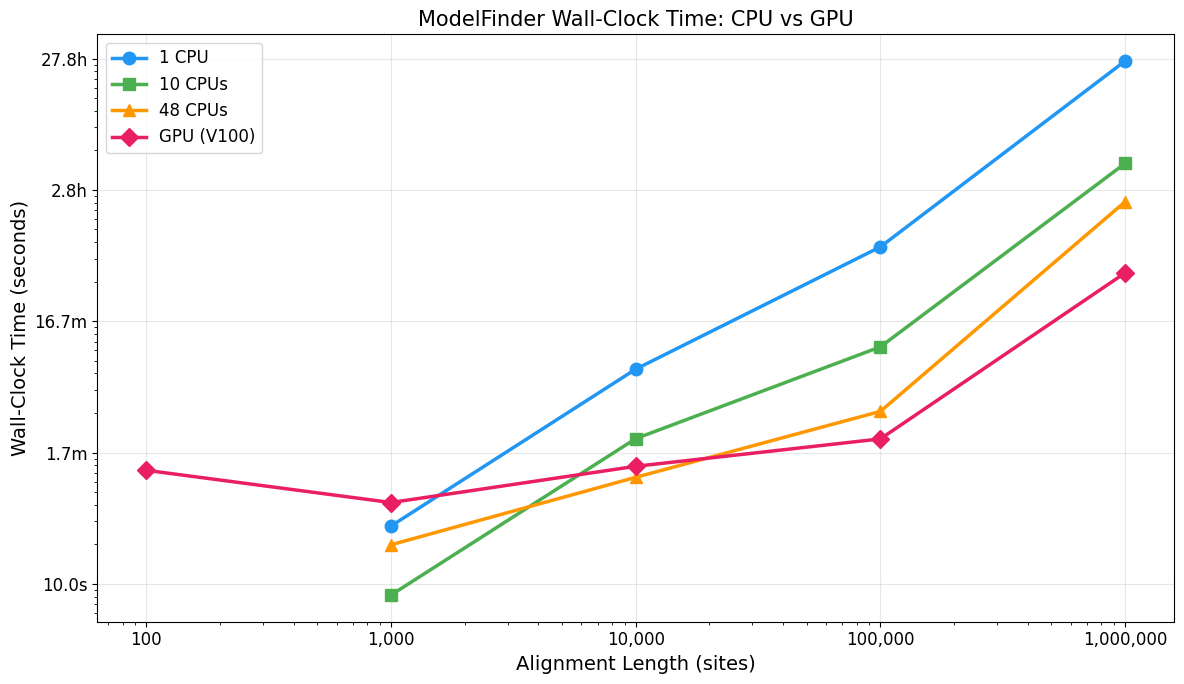

In [8]:
# Wall-clock time plot
fig, ax = plt.subplots(figsize=(12, 7))

for wf in [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in time_pivot.columns]:
    data = time_pivot[wf].dropna()
    ax.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Alignment Length (sites)', fontsize=14)
ax.set_ylabel('Wall-Clock Time (seconds)', fontsize=14)
ax.set_title('ModelFinder Wall-Clock Time: CPU vs GPU', fontsize=15)
ax.legend(fontsize=12, loc='upper left')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: fmt_time(x)))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

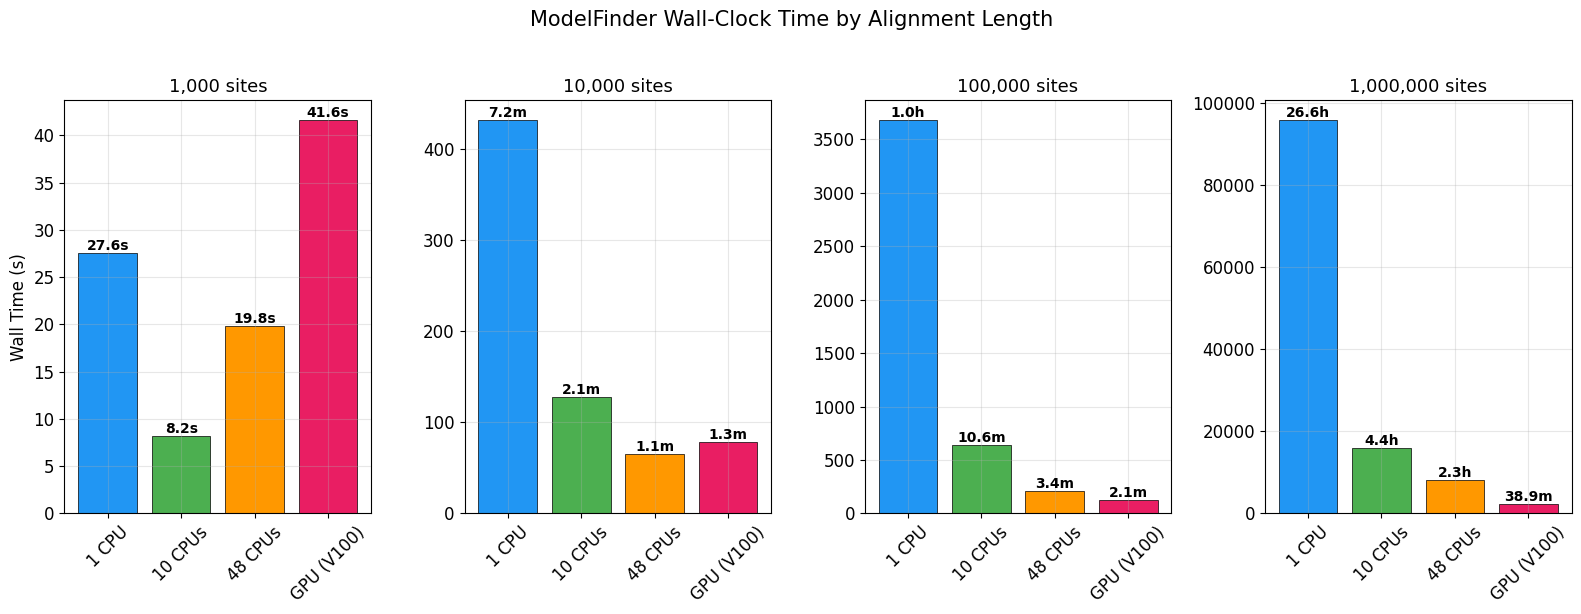

In [9]:
# Bar chart for wall-clock time at each alignment length
available_wfs = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in time_pivot.columns]
# Only plot lengths where we have data for most workflows
valid_lengths = time_pivot.dropna(thresh=3).index

fig, axes = plt.subplots(1, len(valid_lengths), figsize=(4*len(valid_lengths), 6), sharey=False)
if len(valid_lengths) == 1:
    axes = [axes]

for i, length in enumerate(valid_lengths):
    ax = axes[i]
    vals = []
    labels = []
    bar_colors = []
    for wf in available_wfs:
        v = time_pivot.loc[length, wf]
        if not pd.isna(v):
            vals.append(v)
            labels.append(wf)
            bar_colors.append(colors[wf])
    
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{length:,} sites', fontsize=13)
    ax.set_ylabel('Wall Time (s)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('ModelFinder Wall-Clock Time by Alignment Length', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_bars.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Speedup Analysis

In [10]:
# Calculate speedup relative to 1 CPU
if '1 CPU' in time_pivot.columns:
    speedup_df = pd.DataFrame(index=time_pivot.index)
    for wf in available_wfs:
        speedup_df[wf] = time_pivot['1 CPU'] / time_pivot[wf]
    
    print("Speedup vs 1 CPU (wall-clock):")
    print(speedup_df.to_string(float_format='%.2f'))
    print()
    
    # Also show GPU speedup vs 48 CPUs
    if 'GPU (V100)' in time_pivot.columns and '48 CPUs' in time_pivot.columns:
        gpu_vs_48 = time_pivot['48 CPUs'] / time_pivot['GPU (V100)']
        print("GPU speedup vs 48 CPUs:")
        for length in gpu_vs_48.dropna().index:
            print(f"  len={length:>8,}: {gpu_vs_48[length]:.2f}x")

Speedup vs 1 CPU (wall-clock):
         1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                      
100        NaN      NaN      NaN         NaN
1000      1.00     3.35     1.39        0.66
10000     1.00     3.38     6.66        5.49
100000    1.00     5.77    17.89       28.98
1000000   1.00     6.02    11.79       41.06

GPU speedup vs 48 CPUs:
  len=   1,000: 0.48x
  len=  10,000: 0.82x
  len= 100,000: 1.62x
  len=1,000,000: 3.48x


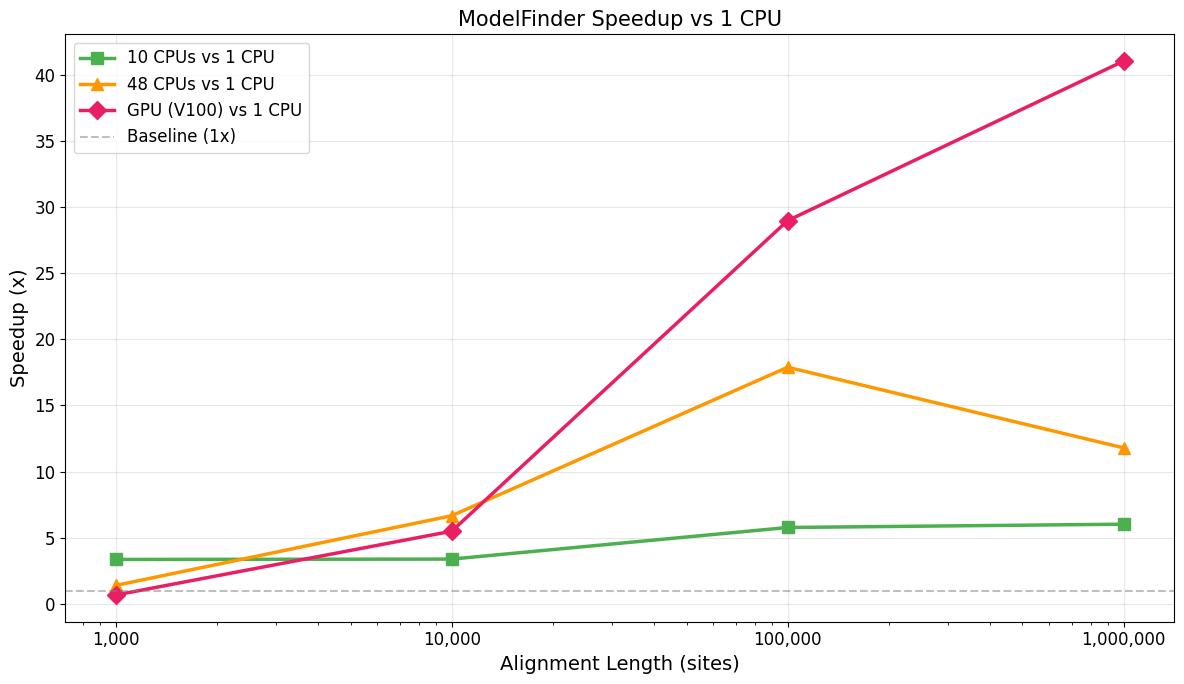

In [11]:
# Speedup plot
if '1 CPU' in time_pivot.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for wf in available_wfs:
        if wf == '1 CPU':
            continue
        data = speedup_df[wf].dropna()
        ax.plot(data.index, data.values, marker=markers[wf], label=f'{wf} vs 1 CPU',
                color=colors[wf], linewidth=2.5, markersize=9)
    
    ax.set_xscale('log')
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Baseline (1x)')
    ax.set_xlabel('Alignment Length (sites)', fontsize=14)
    ax.set_ylabel('Speedup (x)', fontsize=14)
    ax.set_title('ModelFinder Speedup vs 1 CPU', fontsize=15)
    ax.legend(fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'speedup_vs_1cpu.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 6. CPU Time (Total Compute) Comparison

In [12]:
cpu_pivot = df.pivot_table(index='length', columns='workflow_label', values='cpu_time_sec', aggfunc='first')
cpu_pivot = cpu_pivot[[c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in cpu_pivot.columns]]

print("Total CPU time (seconds):")
print(cpu_pivot.to_string(float_format='%.1f'))
print()
print("CPU time (human-readable):")
print(cpu_pivot.map(fmt_time).to_string())
print()

# Parallelism efficiency: CPU_time / wall_time
if '1 CPU' in time_pivot.columns:
    print("\nParallelism overhead (CPU_time / wall_time):")
    for wf in available_wfs:
        ratio = cpu_pivot[wf] / time_pivot[wf]
        for length in ratio.dropna().index:
            print(f"  {wf:>12s}, len={length:>8,}: {ratio[length]:.2f}x")

Total CPU time (seconds):
workflow_label   1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                              
100                NaN      NaN      NaN        71.9
1000              27.4     81.7    937.4        41.6
10000            426.6   1173.6   2946.4        78.4
100000          3644.3   5875.4   9193.6       125.7
1000000        94708.5 147196.1 350156.7      2313.3

CPU time (human-readable):
workflow_label  1 CPU 10 CPUs 48 CPUs GPU (V100)
length                                          
100               N/A     N/A     N/A       1.2m
1000            27.4s    1.4m   15.6m      41.6s
10000            7.1m   19.6m   49.1m       1.3m
100000           1.0h    1.6h    2.6h       2.1m
1000000         26.3h   40.9h   97.3h      38.6m


Parallelism overhead (CPU_time / wall_time):
         1 CPU, len=   1,000: 0.99x
         1 CPU, len=  10,000: 0.99x
         1 CPU, len= 100,000: 0.99x
         1 CPU, len=1,000,000: 0.99x
       10 CPUs, len=   1,000: 9.93x
    

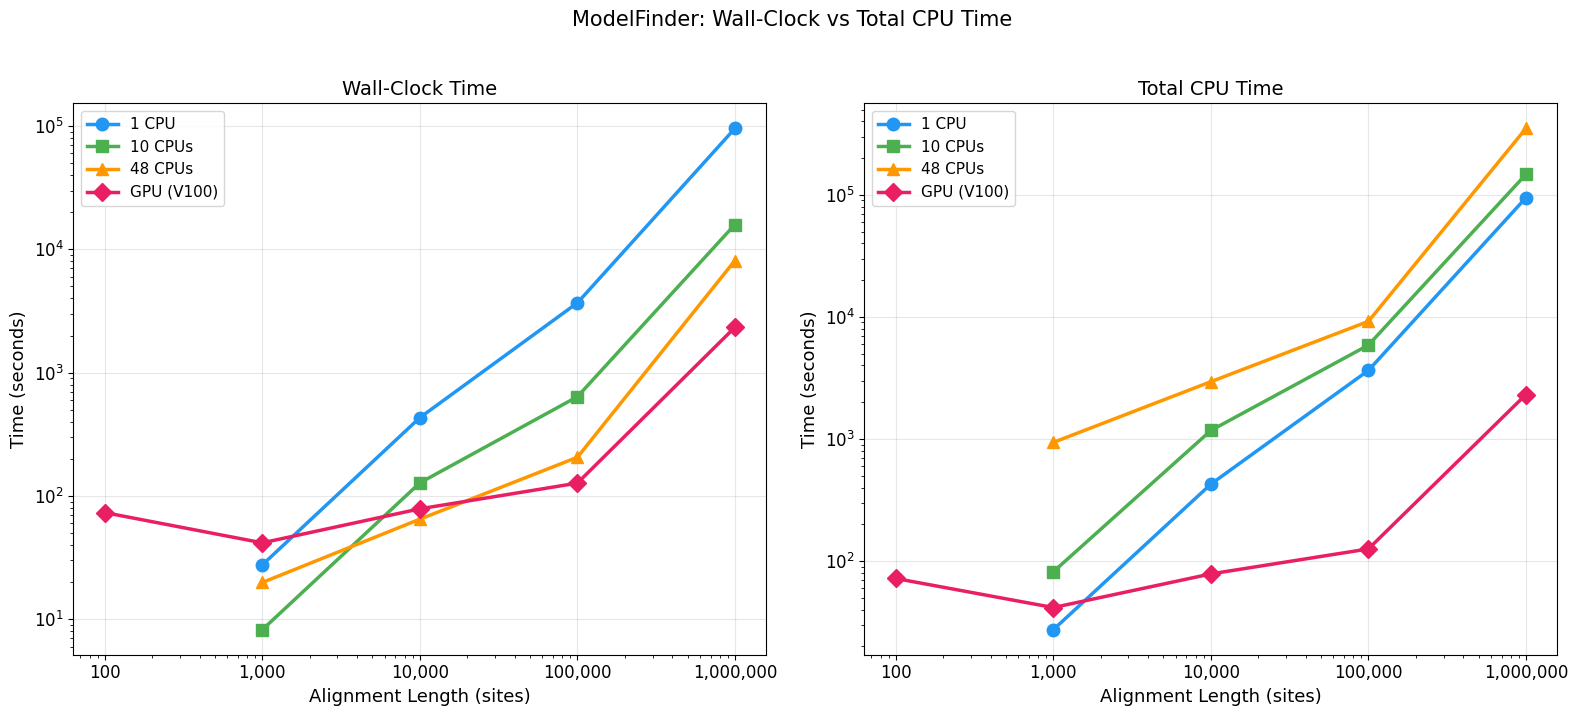

In [13]:
# CPU time vs wall time comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: Wall-clock time
for wf in available_wfs:
    data = time_pivot[wf].dropna()
    ax1.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Alignment Length (sites)', fontsize=13)
ax1.set_ylabel('Time (seconds)', fontsize=13)
ax1.set_title('Wall-Clock Time', fontsize=14)
ax1.legend(fontsize=11)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: CPU time
for wf in available_wfs:
    data = cpu_pivot[wf].dropna()
    ax2.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Alignment Length (sites)', fontsize=13)
ax2.set_ylabel('Time (seconds)', fontsize=13)
ax2.set_title('Total CPU Time', fontsize=14)
ax2.legend(fontsize=11)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('ModelFinder: Wall-Clock vs Total CPU Time', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_vs_cpu_time.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. BIC / AIC Score Comparison

In [14]:
if 'bic' in df.columns:
    bic_pivot = df.pivot_table(index='length', columns='workflow_label', values='bic', aggfunc='first')
    bic_cols = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in bic_pivot.columns]
    bic_pivot = bic_pivot[bic_cols]
    
    print("BIC scores:")
    print(bic_pivot.to_string(float_format='%.4f'))
    print()
    
    # Check BIC agreement
    if '1 CPU' in bic_pivot.columns:
        print("BIC difference from 1 CPU baseline:")
        for col in bic_cols:
            if col != '1 CPU':
                diff = (bic_pivot[col] - bic_pivot['1 CPU']).dropna()
                for idx in diff.index:
                    print(f"  len={idx:>8,}, {col:>12s}: Δ = {diff[idx]:.6f}")

if 'gamma_alpha' in df.columns:
    gamma_pivot = df.pivot_table(index='length', columns='workflow_label', values='gamma_alpha', aggfunc='first')
    gamma_cols = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in gamma_pivot.columns]
    gamma_pivot = gamma_pivot[gamma_cols]
    print("\nGamma shape alpha:")
    print(gamma_pivot.to_string(float_format='%.4f'))

BIC scores:
workflow_label          1 CPU        10 CPUs        48 CPUs     GPU (V100)
length                                                                    
100                       NaN            NaN            NaN     10741.0944
1000              113752.7611    113752.7611    113752.7611    113752.7611
10000            1130268.8308   1130268.8319   1130268.8308   1130268.8317
100000          11388283.1765  11388283.1765  11388283.1765  11388283.1765
1000000        118418815.3406 118418815.3406 118418815.3406 118418815.3406

BIC difference from 1 CPU baseline:
  len=   1,000,      10 CPUs: Δ = 0.000000
  len=  10,000,      10 CPUs: Δ = 0.001100
  len= 100,000,      10 CPUs: Δ = 0.000000
  len=1,000,000,      10 CPUs: Δ = 0.000000
  len=   1,000,      48 CPUs: Δ = 0.000000
  len=  10,000,      48 CPUs: Δ = 0.000000
  len= 100,000,      48 CPUs: Δ = 0.000000
  len=1,000,000,      48 CPUs: Δ = 0.000000
  len=   1,000,   GPU (V100): Δ = 0.000000
  len=  10,000,   GPU (V100): Δ = 0.0

## 8. Summary: GPU vs Best CPU

In [15]:
if 'GPU (V100)' in time_pivot.columns:
    summary_rows = []
    for length in time_pivot.index:
        gpu_time = time_pivot.loc[length, 'GPU (V100)']
        if pd.isna(gpu_time):
            continue
        
        row = {'Sites': f'{length:,}'}
        row['GPU Wall Time'] = fmt_time(gpu_time)
        
        for wf in ['1 CPU', '10 CPUs', '48 CPUs']:
            if wf in time_pivot.columns:
                cpu_time = time_pivot.loc[length, wf]
                if not pd.isna(cpu_time):
                    row[f'{wf} Wall Time'] = fmt_time(cpu_time)
                    speedup = cpu_time / gpu_time
                    row[f'GPU vs {wf}'] = f'{speedup:.2f}x' if speedup >= 1 else f'{1/speedup:.2f}x slower'
        
        # Log-likelihood match
        gpu_lnl = lnl_pivot.loc[length, 'GPU (V100)'] if 'GPU (V100)' in lnl_pivot.columns else None
        cpu_lnl = lnl_pivot.loc[length, '1 CPU'] if '1 CPU' in lnl_pivot.columns else None
        if gpu_lnl is not None and cpu_lnl is not None and not pd.isna(gpu_lnl) and not pd.isna(cpu_lnl):
            row['lnL Match'] = f'Δ={abs(gpu_lnl - cpu_lnl):.6f}'
        
        summary_rows.append(row)
    
    summary_df = pd.DataFrame(summary_rows)
    print("=" * 100)
    print("SUMMARY: GPU (V100) vs CPU Workflows for ModelFinder")
    print("=" * 100)
    print(summary_df.to_string(index=False))

SUMMARY: GPU (V100) vs CPU Workflows for ModelFinder
    Sites GPU Wall Time 1 CPU Wall Time GPU vs 1 CPU 10 CPUs Wall Time GPU vs 10 CPUs 48 CPUs Wall Time GPU vs 48 CPUs  lnL Match
      100          1.2m             NaN          NaN               NaN            NaN               NaN            NaN        NaN
    1,000         41.6s           27.6s 1.51x slower              8.2s   5.06x slower             19.8s   2.10x slower Δ=0.000000
   10,000          1.3m            7.2m        5.49x              2.1m          1.62x              1.1m   1.21x slower Δ=0.000400
  100,000          2.1m            1.0h       28.98x             10.6m          5.02x              3.4m          1.62x Δ=0.000000
1,000,000         38.9m           26.6h       41.06x              4.4h          6.82x              2.3h          3.48x Δ=0.000000


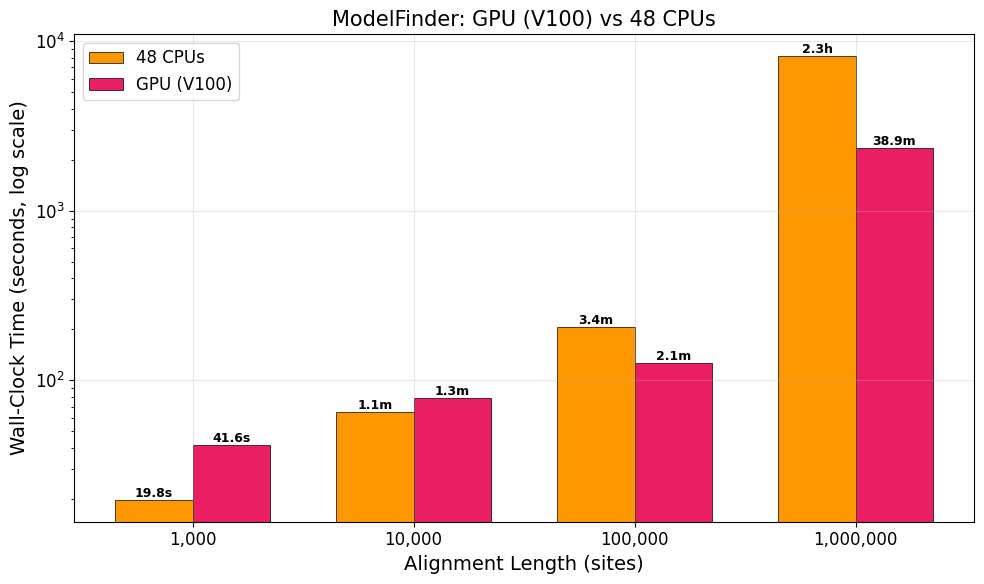

In [16]:
# Final summary bar chart: GPU vs 48 CPUs speedup
if 'GPU (V100)' in time_pivot.columns and '48 CPUs' in time_pivot.columns:
    common_idx = time_pivot[['GPU (V100)', '48 CPUs']].dropna().index
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_labels = [f'{l:,}' for l in common_idx]
    gpu_times = [time_pivot.loc[l, 'GPU (V100)'] for l in common_idx]
    cpu48_times = [time_pivot.loc[l, '48 CPUs'] for l in common_idx]
    
    x = np.arange(len(x_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, cpu48_times, width, label='48 CPUs', color=colors['48 CPUs'], edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, gpu_times, width, label='GPU (V100)', color=colors['GPU (V100)'], edgecolor='black', linewidth=0.5)
    
    # Add time labels
    for bar, v in zip(bars1, cpu48_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar, v in zip(bars2, gpu_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)', fontsize=14)
    ax.set_ylabel('Wall-Clock Time (seconds, log scale)', fontsize=14)
    ax.set_title('ModelFinder: GPU (V100) vs 48 CPUs', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'gpu_vs_48cpu_bars.png'), dpi=150, bbox_inches='tight')
    plt.show()